In [27]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv




In [2]:
# Raw data


# Clinical Data
df = pl.read_csv("../data/raw/X_train/clinical_train.csv")
df_eval = pl.read_csv("../data/raw/X_test/clinical_test.csv")

# Molecular Data
mol_df = pl.read_csv("../data/raw/X_train/molecular_train.csv")
mol_eval = pl.read_csv("../data/raw/X_test/molecular_test.csv" , ignore_errors=True)


target_df = pl.read_csv("../data/raw/target_train.csv")

# EDA 

In [3]:
df.head()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,f64,f64,f64,str
"""P132697""","""MSK""",14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…"
"""P132698""","""MSK""",1.0,7.4,2.4,0.1,11.6,42.0,"""46,xx"""
"""P116889""","""MSK""",15.0,3.7,2.1,0.1,14.2,81.0,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…"
"""P132699""","""MSK""",1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…"
"""P132700""","""MSK""",6.0,128.0,9.7,0.9,11.1,195.0,"""46,xx,t(3;9)(p13;q22)[10]/46,x…"


In [4]:
df.shape

(3323, 9)

In [5]:
df.describe()

statistic,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,str,f64,f64,f64,f64,f64,f64,str
"""count""","""3323""","""3323""",3214.0,3051.0,3130.0,2722.0,3213.0,3199.0,"""2936"""
"""null_count""","""0""","""0""",109.0,272.0,193.0,601.0,110.0,124.0,"""387"""
"""mean""",null,null,5.982545,6.535164,3.264735,0.955868,9.893549,167.0489,null
"""std""",null,null,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031,null
"""min""","""P100000""","""CCH""",0.0,0.2,0.0,0.0,4.0,2.0,"""+8(fish)"""
"""25%""",null,null,1.0,2.7,1.0,0.15,8.5,66.0,null
"""50%""",null,null,3.0,4.1,2.0,0.37,9.7,123.0,null
"""75%""",null,null,8.0,6.66,3.69,0.784,11.2,230.0,null
"""max""","""P132729""","""VU""",91.0,154.4,109.62,44.2,16.6,1451.0,"""tris8"""


In [6]:
df["CENTER"].value_counts() # The clinical center where the patient is treated.

CENTER,count
str,u32
"""RMCN""",199
"""CGM""",107
"""GESMD""",246
"""PV""",316
"""HIAE""",47
…,…
"""MUV""",83
"""UMG""",26
"""CCH""",159


In [7]:
mol_df.head() # Molecular data set

ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
str,str,f64,f64,str,str,str,str,str,f64,f64
"""P100000""","""11""",1.19149248e8,1.19149248e8,"""G""","""A""","""CBL""","""p.C419Y""","""non_synonymous_codon""",0.083,1308.0
"""P100000""","""5""",1.31822301e8,1.31822301e8,"""G""","""T""","""IRF1""","""p.Y164*""","""stop_gained""",0.022,532.0
"""P100000""","""3""",7.769406e7,7.769406e7,"""G""","""C""","""ROBO2""","""p.?""","""splice_site_variant""",0.41,876.0
"""P100000""","""4""",1.06164917e8,1.06164917e8,"""G""","""T""","""TET2""","""p.R1262L""","""non_synonymous_codon""",0.43,826.0
"""P100000""","""2""",2.5468147e7,2.5468163e7,"""ACGAAGAGGGGGTGTTC""","""A""","""DNMT3A""","""p.E505fs*141""","""frameshift_variant""",0.0898,942.0


In [8]:
mol_df.shape

(10935, 11)

In [9]:
# Number of unique patients
mol_df["ID"].unique()

ID
str
"""P121141"""
"""P121046"""
"""P110457"""
"""P102944"""
"""P118447"""
…
"""P118484"""
"""P116531"""
"""P117174"""


In [10]:
mol_df["CHR"].unique() # Number of all possible mutations

CHR
str
"""18"""
"""6"""
"""2"""
"""1"""
"""10"""
…
"""21"""
null
"""17"""


In [11]:
mol_df.group_by("ID").agg(pl.col("CHR").count()) # Distribution of the number of mutations per patient

ID,CHR
str,u32
"""P100208""",3
"""P116430""",6
"""P117159""",3
"""P105721""",5
"""P102723""",5
…,…
"""P102940""",2
"""P121086""",7
"""P122496""",2


In [12]:
mol_df["GENE"].value_counts().sort(by="count" , descending=True).head(5) # The 5 most affected genes 

GENE,count
str,u32
"""TET2""",1663
"""ASXL1""",951
"""SF3B1""",775
"""DNMT3A""",604
"""RUNX1""",578


In [13]:
target_df.head()

ID,OS_YEARS,OS_STATUS
str,f64,f64
"""P132697""",1.115068,1.0
"""P132698""",4.928767,0.0
"""P116889""",2.043836,0.0
"""P132699""",2.476712,1.0
"""P132700""",3.145205,0.0


In [14]:
target_df["OS_STATUS"].value_counts()

OS_STATUS,count
f64,u32
null,150
1.0,1600
0.0,1573


In [15]:
target_df.describe()

statistic,ID,OS_YEARS,OS_STATUS
str,str,f64,f64
"""count""","""3323""",3173.0,3173.0
"""null_count""","""0""",150.0,150.0
"""mean""",null,2.480713,0.504255
"""std""",null,2.588259,0.500061
"""min""","""P100000""",0.0,0.0
"""25%""",null,0.652055,0.0
"""50%""",null,1.652055,1.0
"""75%""",null,3.572603,1.0
"""max""","""P132729""",22.043836,1.0


In [16]:
# Checking the consistency of ID's

clinical_id = df["ID"].unique().to_numpy()
y_train_id = target_df["ID"].unique().to_numpy()
molecular_id = mol_df["ID"].unique().to_numpy()


cpt_clinical = 0
cpt_molecular  = 0

for id in y_train_id:
    if id not in clinical_id :
        cpt_clinical+=1
    elif id not in molecular_id:
        cpt_molecular+=1


print(f"In total , there are {cpt_molecular} missing id's in molecular data frame ! ")
print(f"In total , there are {cpt_clinical} missing id's in clinical data frame ! ")


In total , there are 297 missing id's in molecular data frame ! 
In total , there are 0 missing id's in clinical data frame ! 


In [17]:
df.filter(df.is_duplicated()) # Check for duplicated id's in clinical data frame

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,f64,f64,f64,str


In [18]:
target_df.filter(target_df.is_duplicated()) # Check for duplicated id's in target data frame

ID,OS_YEARS,OS_STATUS
str,f64,f64


In [19]:
df.null_count() # Null count for clinical data frame

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,109,272,193,601,110,124,387


In [20]:
mol_df.null_count() # Null count for molecular data frame

ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,114,114,114,114,114,0,12,0,89,114


In [21]:
target_df.null_count() # Null count for target

ID,OS_YEARS,OS_STATUS
u32,u32,u32
0,150,150


# VISUALIZATION

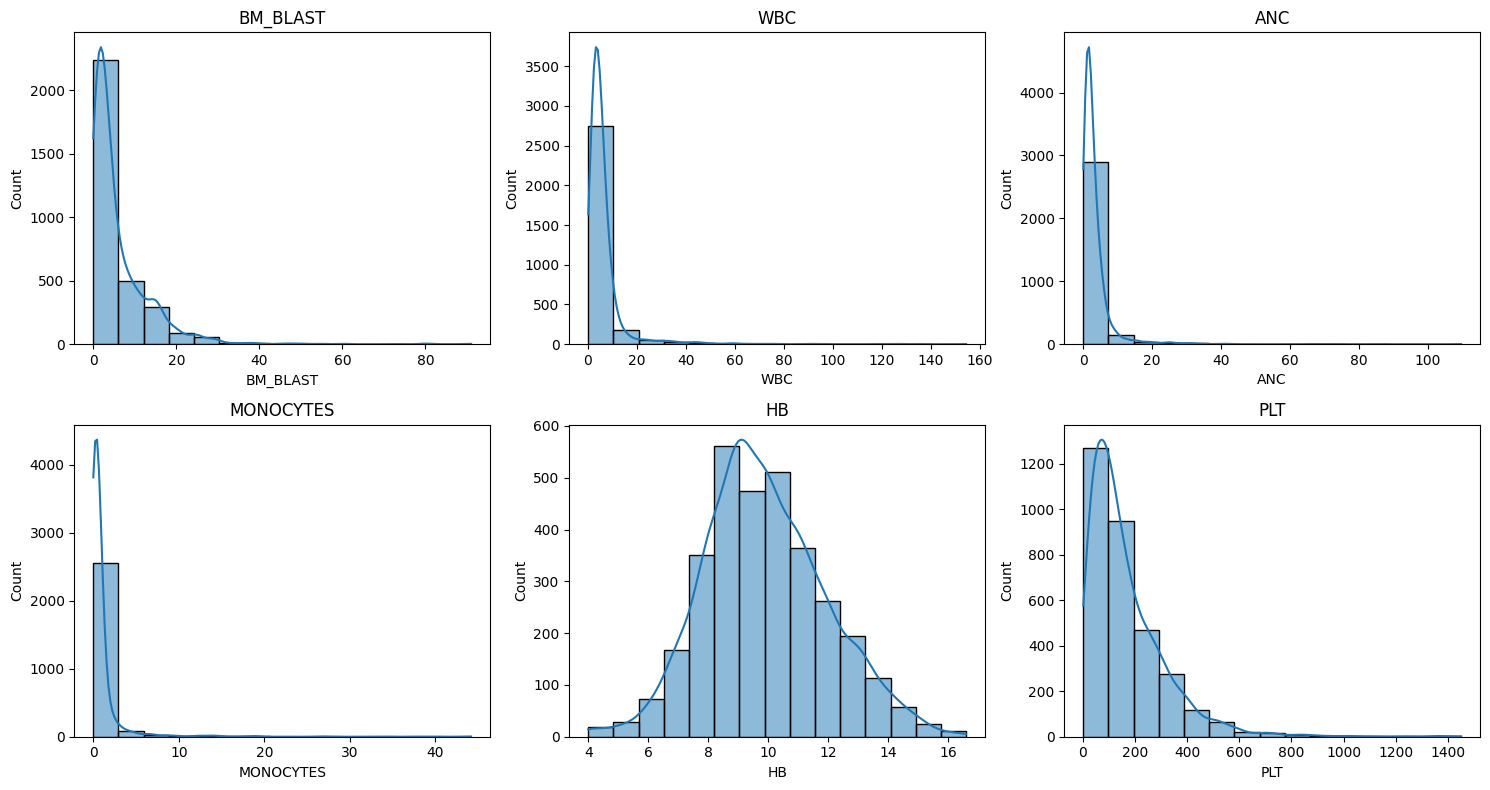

In [53]:


cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

rows = 2
cols = 3

plt.figure(figsize=(15, 8)) 

for index, var in enumerate(cl_quantitative_var):
    plt.subplot(rows, cols, index + 1)
    sns.histplot(data=df, x=var, bins=15, kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()


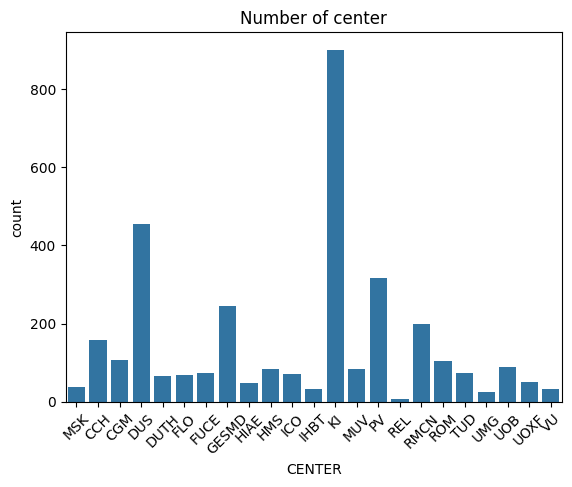

In [ ]:
# Number of center 
sns.countplot(data=df,x="CENTER")
plt.xticks(rotation=45)
plt.title("Number of center")
plt.show()

C:\Users\zakar\AppData\Local\Temp\ipykernel_10588\1981360173.py:13: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


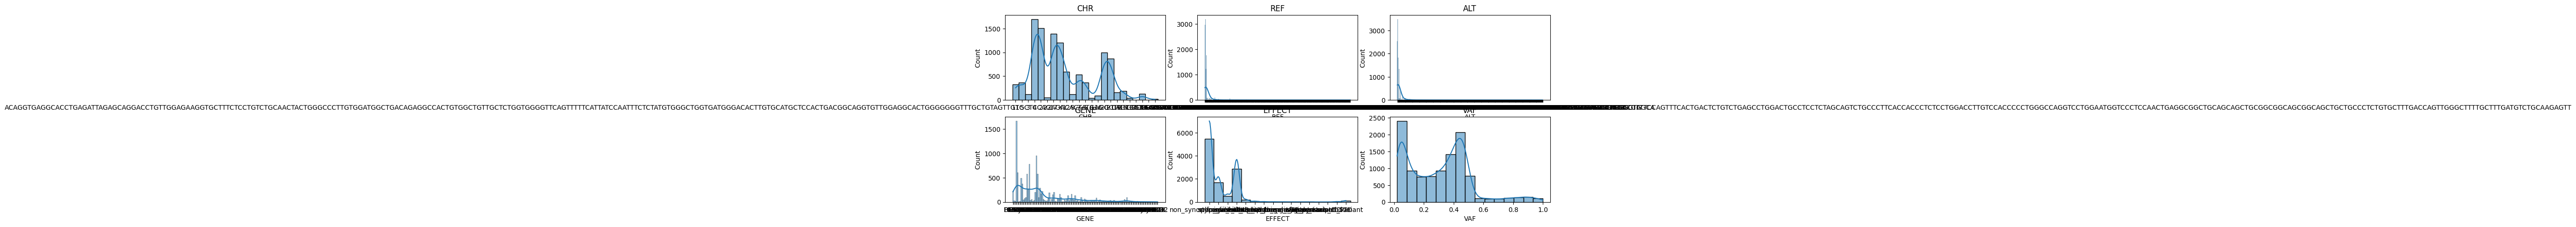

In [ ]:
molecular_df = ["CHR" , "REF" , "ALT" , "GENE" , "EFFECT" , "VAF"]

rows = 3
cols = 3

plt.figure(figsize=(15, 8)) 

for index, var in enumerate(molecular_df):
    plt.subplot(rows, cols, index + 1)
    sns.histplot(data=mol_df, x=var, bins=15, kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()


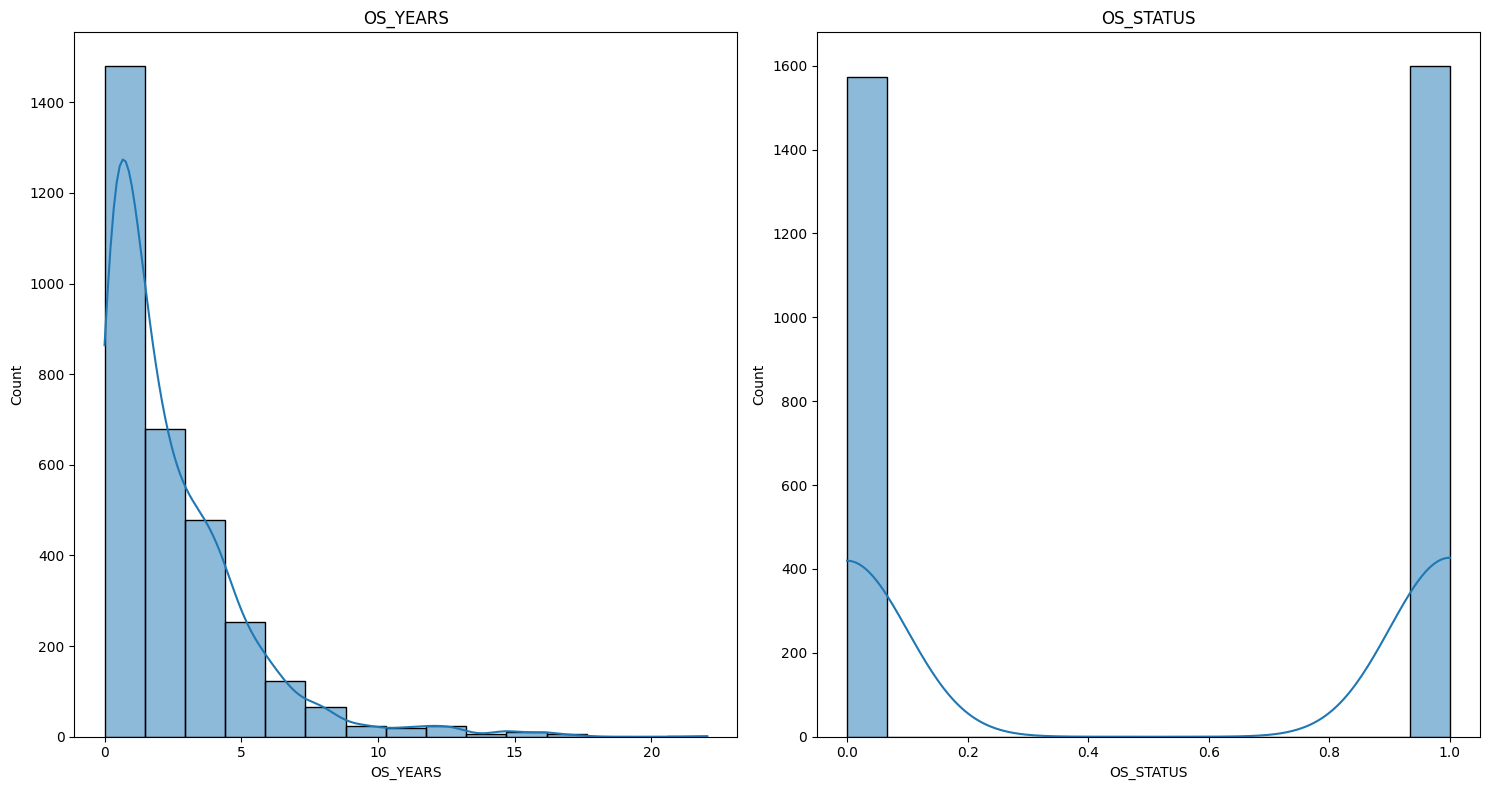

In [56]:
target_cl = ["OS_YEARS" , "OS_STATUS"]

rows = 1
cols = 2

plt.figure(figsize=(15, 8)) 

for index, var in enumerate(target_cl):
    plt.subplot(rows, cols, index + 1)
    sns.histplot(data=target_df, x=var, bins=15, kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()


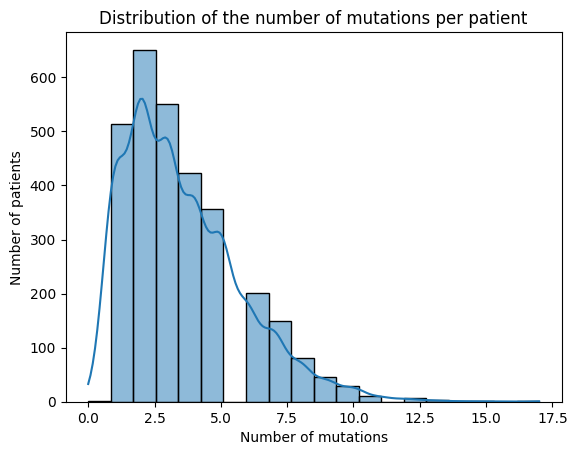

In [63]:
mutation_counts = mol_df.group_by("ID").agg(pl.col("CHR").count().alias("n_mutations"))
sns.histplot(data=mutation_counts, x="n_mutations", bins=20, kde=True)
plt.title("Distribution of the number of mutations per patient")
plt.xlabel("Number of mutations")
plt.ylabel("Number of patients")
plt.show()

In [70]:
# Patients with no mutations

for patients in clinical_id:
    if patients not in molecular_id:
        print(f"The patient {patients} has no mutation ! ")
        

The patient P131509 has no mutation ! 
The patient P116558 has no mutation ! 
The patient P118401 has no mutation ! 
The patient P116444 has no mutation ! 
The patient P122500 has no mutation ! 
The patient P122311 has no mutation ! 
The patient P110838 has no mutation ! 
The patient P100271 has no mutation ! 
The patient P120825 has no mutation ! 
The patient P117429 has no mutation ! 
The patient P105810 has no mutation ! 
The patient P116350 has no mutation ! 
The patient P117431 has no mutation ! 
The patient P105767 has no mutation ! 
The patient P117398 has no mutation ! 
The patient P118477 has no mutation ! 
The patient P105552 has no mutation ! 
The patient P105953 has no mutation ! 
The patient P118495 has no mutation ! 
The patient P131517 has no mutation ! 
The patient P102575 has no mutation ! 
The patient P100365 has no mutation ! 
The patient P117986 has no mutation ! 
The patient P116366 has no mutation ! 
The patient P106258 has no mutation ! 
The patient P103055 has n